# DeepKalmanFilter on MNIST

Training a DKF on sequences of MNIST digit rows — each image row is fed as an observation at time step $t$. The DKF learns to model the latent dynamics of the image.

**Data format:**
- Each 28x28 image becomes a sequence of 28 rows of 28 pixels
- $T = 28$ (time steps), $obs\_dim = 28$ (pixels per row)
- Binary data: using Bernoulli emission


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from kalman.dkf import DeepKalmanFilter
from kalman.gaussian import GaussianState

torch.manual_seed(42)
device = 'cpu'


## 1. Loading and preparing MNIST

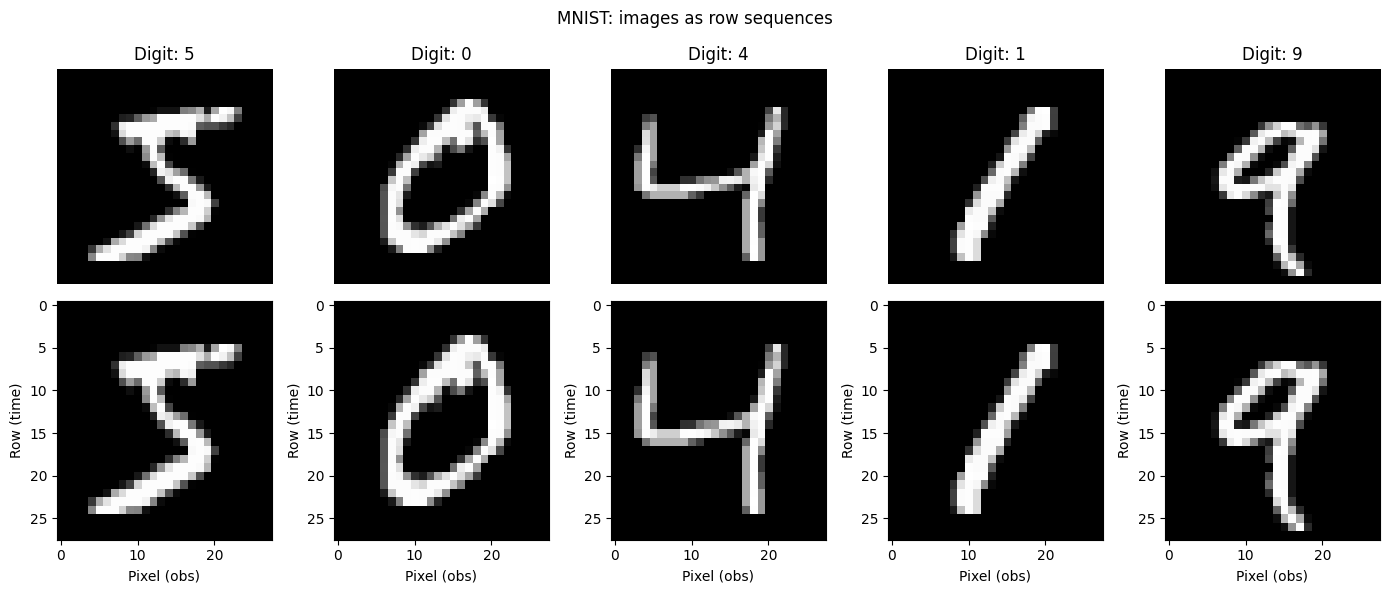

In [2]:
# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use a subset for faster training
train_subset = torch.utils.data.Subset(train_dataset, range(5000))
test_subset = torch.utils.data.Subset(test_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

# Visualization: how an image looks as a sequence of rows
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    img = train_dataset[i][0].squeeze()
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Digit: {train_dataset[i][1]}')
    axes[0, i].axis('off')
    
    # Show as sequence of rows
    axes[1, i].imshow(img.numpy(), cmap='gray', aspect='auto')
    axes[1, i].set_ylabel('Row (time)')
    axes[1, i].set_xlabel('Pixel (obs)')
    
plt.suptitle('MNIST: images as row sequences')
plt.tight_layout()
plt.show()


## 2. Creating and training DKF

In [3]:
state_dim = 8
obs_dim = 28  # MNIST width

params = {
    'dataset': 'mnist',
    'transition_type': 'mlp',
    'transition_layers': 2,
    'emission_type': 'mlp',
    'emission_layers': 2,
    'data_type': 'binary',
    'dim_hidden': 128,
    'var_model': 'LR',
    'rnn_size': 128,
    'rnn_layers': 1,
    'inference_model': 'mean_field',
    'use_prev_input': False,
}

model = DeepKalmanFilter(state_dim=state_dim, obs_dim=obs_dim, params=params).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 365,516


In [ ]:
n_epochs = 20
train_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss, epoch_nll, epoch_kl, n_batches = 0, 0, 0, 0
    
    # KL annealing
    model.anneal = min(1.0, epoch / 10.0)
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.squeeze(1).to(device)  # (B, 28, 28)
        # Convert to (T, B, obs_dim): image rows = time steps
        x = data.permute(1, 0, 2)  # (28, B, 28)
        mask = torch.ones(x.shape[0], x.shape[1], device=device)
        
        optimizer.zero_grad()
        loss, nll, kl = model.loss(x, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_nll += nll.item()
        epoch_kl += kl.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    avg_nll = epoch_nll / n_batches
    avg_kl = epoch_kl / n_batches
    train_losses.append({'loss': avg_loss, 'nll': avg_nll, 'kl': avg_kl})
    
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:2d}: loss={avg_loss:.1f}, nll={avg_nll:.1f}, kl={avg_kl:.1f}, anneal={model.anneal:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([d['loss'] for d in train_losses], label='Total Loss')
ax.plot([d['nll'] for d in train_losses], label='NLL')
ax.plot([d['kl'] for d in train_losses], label='KL')
ax.set_xlabel('Epoch'); ax.legend(); ax.set_title('DKF Training on MNIST')
plt.tight_layout(); plt.show()


/home/kreinin.mv/university/Kalman-filter-and-his-friends/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  0: loss=16481.6, nll=16481.6, kl=217064.9, anneal=0.00
Epoch  5: loss=7154.7, nll=5179.4, kl=3950.6, anneal=0.50
Epoch 10: loss=8353.7, nll=5135.6, kl=3218.1, anneal=1.00
Epoch 15: loss=8192.5, nll=5019.0, kl=3173.5, anneal=1.00


## 3. Image reconstruction

In [ ]:
model.eval()
# Take a test batch
test_data, test_labels = next(iter(test_loader))
test_data = test_data.squeeze(1).to(device)  # (B, 28, 28)
x = test_data.permute(1, 0, 2)  # (28, B, 28)

with torch.no_grad():
    z, mu, log_var = model.infer(x)
    z_state = GaussianState(mu, torch.ones_like(mu))
    recon_probs, _ = model._get_emission(z_state)

# Visualization: original vs reconstruction
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
for i in range(n_show):
    # Original
    axes[0, i].imshow(test_data[i].numpy(), cmap='gray')
    axes[0, i].set_title(f'{test_labels[i].item()}')
    axes[0, i].axis('off')
    
    # Reconstruction
    recon = recon_probs[:, i].numpy()  # (28, 28)
    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstruction')
plt.suptitle('DKF: MNIST reconstruction')
plt.tight_layout(); plt.show()


## 4. Latent space

In [ ]:
# Visualize latent representations by class
from sklearn.decomposition import PCA

all_z = []
all_labels = []

model.eval()
with torch.no_grad():
    for data, labels in test_loader:
        data = data.squeeze(1).to(device)
        x = data.permute(1, 0, 2)
        z, mu, _ = model.infer(x)
        # Average over time
        z_mean = mu.mean(dim=0)  # (B, state_dim)
        all_z.append(z_mean.numpy())
        all_labels.append(labels.numpy())

all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

# PCA to 2D if state_dim > 2
if state_dim > 2:
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(all_z)
else:
    z_2d = all_z

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=all_labels, cmap='tab10', s=10, alpha=0.6)
plt.colorbar(scatter, label='Digit')
ax.set_xlabel('z1'); ax.set_ylabel('z2')
ax.set_title('DKF: MNIST latent space (time-averaged)')
plt.tight_layout(); plt.show()


## Summary

- DKF successfully trains on MNIST in the row-sequence format
- The model reconstructs images from latent space
- Latent representations cluster by digit class
- Training is stable: loss and NLL decrease, KL is controlled via annealing
